<a href="https://colab.research.google.com/github/MinoliPerera021126/multi-class-species-classification-with-pytorch-neural-network/blob/main/iris_image_classification_with_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Connect to Kaggle and Download the Dataset
- Before running this cell, you need to go to your Kaggle account settings, click **"Create New API Token"**, and download the `kaggle.json` file.

In [1]:
# Install kaggle library
!pip install -q kaggle

# Prompt to upload your kaggle.json file
from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Set up the Kaggle directory and permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip the dataset
!kaggle datasets download -d alxmamaev/flowers-recognition
!unzip -q flowers-recognition.zip -d dataset/
print("Dataset downloaded and unzipped successfully!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
100% 225M/225M [00:11<00:00, 20.7MB/s]

Dataset downloaded and unzipped successfully!


### 2. Import PyTorch and Set Up DeviceImport PyTorch and Set Up Device

In [11]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set device to GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 3. Data Transformations and Loading

In [12]:
# Define how we want to alter/format our images
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize all images to 224x224 pixels
    transforms.ToTensor(),         # Convert images to PyTorch tensors (0 to 1 scale)
    transforms.Normalize(          # Normalize using standard ImageNet mean and std dev
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# The path where our images were unzipped
data_dir = 'dataset/flowers'

# Load the dataset using ImageFolder (automatically assigns labels based on folder names)
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Print the classes found
classes = full_dataset.classes
print(f"Classes found: {classes}")

# Split the dataset: 80% for training, 20% for testing/validation
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# Create DataLoaders to feed the data to our model in batches of 32 images at a time
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training images: {len(train_dataset)} | Testing images: {len(test_dataset)}")

Classes found: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Training images: 3453 | Testing images: 864


### 4. Define the CNN Model Architecture

In [13]:
class FlowerClassifier(nn.Module):
    def __init__(self, num_classes):
        super(FlowerClassifier, self).__init__()

        # --- CONVOLUTIONAL LAYERS ---
        # Using nn.Sequential makes the forward pass much cleaner
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # --- FULLY CONNECTED LAYERS ---
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 28 * 28, 512)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # 1. Pass the image through ALL the conv layers at once
        x = self.features(x)

        # 2. Flatten the 2D maps into a 1D array
        x = self.flatten(x)

        # 3. Pass through the fully connected layers
        x = self.relu4(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the model and move it to our GPU/CPU
model = FlowerClassifier(num_classes=len(classes)).to(device)
print(model)

FlowerClassifier(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (relu4): Re

### 5. Loss Function and Optimizer

In [14]:
# CrossEntropyLoss is standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer is highly effective
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

### 6. The Training Loop

In [15]:
epochs = 25

for epoch in range(epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # 1. Forward pass
        outputs = model(images)

        # 2. Calculate the loss
        loss = criterion(outputs, labels)

        # 3. Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track accuracy and loss
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    # 4. Step the scheduler using the training loss (since we don't have val_loss yet)
    scheduler.step(epoch_loss)

    # Get current learning rate to print it (optional, but helpful to see it working!)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}% - LR: {current_lr}")

Epoch [1/25] - Loss: 4.6972 - Accuracy: 45.58% - LR: 0.001
Epoch [2/25] - Loss: 1.0562 - Accuracy: 57.66% - LR: 0.001
Epoch [3/25] - Loss: 0.9398 - Accuracy: 62.44% - LR: 0.001
Epoch [4/25] - Loss: 0.8383 - Accuracy: 67.74% - LR: 0.001
Epoch [5/25] - Loss: 0.7899 - Accuracy: 69.91% - LR: 0.001
Epoch [6/25] - Loss: 0.7044 - Accuracy: 72.69% - LR: 0.001
Epoch [7/25] - Loss: 0.6615 - Accuracy: 74.83% - LR: 0.001
Epoch [8/25] - Loss: 0.6160 - Accuracy: 76.31% - LR: 0.001
Epoch [9/25] - Loss: 0.5102 - Accuracy: 80.74% - LR: 0.001
Epoch [10/25] - Loss: 0.4536 - Accuracy: 83.55% - LR: 0.001
Epoch [11/25] - Loss: 0.3593 - Accuracy: 86.82% - LR: 0.001
Epoch [12/25] - Loss: 0.2692 - Accuracy: 89.98% - LR: 0.001
Epoch [13/25] - Loss: 0.2659 - Accuracy: 90.67% - LR: 0.001
Epoch [14/25] - Loss: 0.2476 - Accuracy: 91.08% - LR: 0.001
Epoch [15/25] - Loss: 0.1421 - Accuracy: 95.31% - LR: 0.001
Epoch [16/25] - Loss: 0.1162 - Accuracy: 96.26% - LR: 0.001
Epoch [17/25] - Loss: 0.1261 - Accuracy: 95.60% -

### 7. Testing and Visualizing Predictions

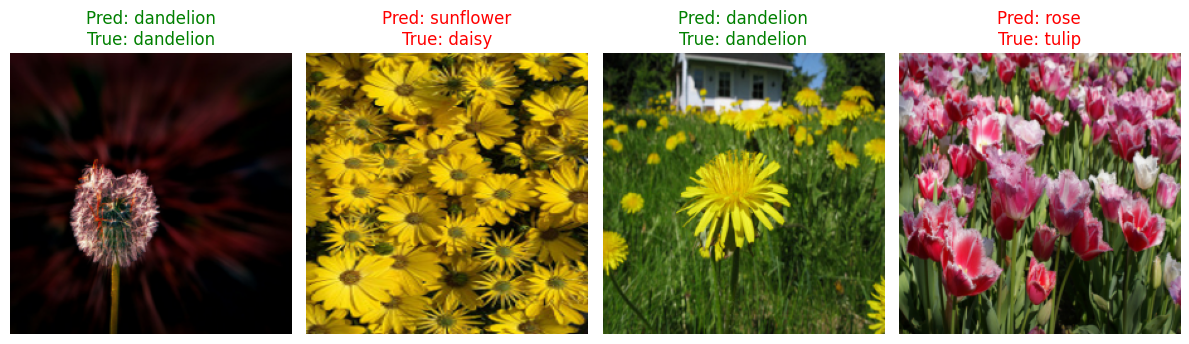

In [16]:
# Un-normalize function so we can display the images nicely using matplotlib
def imshow(img):
    img = img.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')

model.eval() # Set model to evaluation mode (turns off dropout/batchnorm updates)

# Grab one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Make predictions
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Plot the first 4 images in the batch with their predicted vs true labels
fig = plt.figure(figsize=(12, 4))
for idx in range(4):
    ax = fig.add_subplot(1, 4, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(f"Pred: {classes[predicted[idx]]}\nTrue: {classes[labels[idx]]}",
                 color=("green" if predicted[idx]==labels[idx] else "red"))
plt.tight_layout()
plt.show()

### 8. Plot Confusion Matrix

              precision    recall  f1-score   support

       daisy       0.63      0.69      0.66       153
   dandelion       0.67      0.76      0.71       207
        rose       0.63      0.50      0.56       164
   sunflower       0.78      0.71      0.74       150
       tulip       0.58      0.58      0.58       190

    accuracy                           0.65       864
   macro avg       0.66      0.65      0.65       864
weighted avg       0.65      0.65      0.65       864



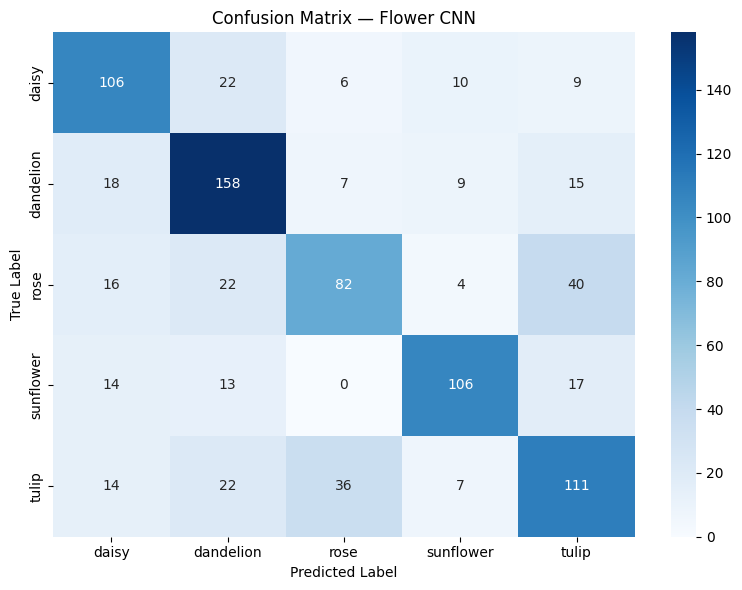

In [17]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# Classification report
print(classification_report(all_labels, all_preds, target_names=classes))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix — Flower CNN')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()